In [37]:
!pip install spacy
!python -m spacy download en_core_web_sm
import spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [38]:
!pip install roboflow
!pip install ultralytics pydantic JSON-minify
import os
from roboflow import Roboflow
from ultralytics import YOLO

In [39]:
!pip install easyocr
import easyocr
print("EasyOCR OK!")

EasyOCR OK!


In [44]:
import os
import shutil
import zipfile
from google.colab import userdata
from roboflow import Roboflow
from ultralytics import YOLO

rf = Roboflow(api_key=userdata.get("api_key"))
project = rf.workspace("-jjvtu").project("receipts-1fkqg-wke0i")
version = project.version(1)
dataset = version.download("yolov8")

model = YOLO("yolov8n.pt")
results = model.train(
    data="/content/Receipts-1/data.yaml",
    epochs=50,
    imgsz=192,
    batch=16,
    device=0
)
metrics = model.val(data="/content/Receipts-1/data.yaml", split="test")
print(metrics.box.map50, metrics.box.map)

loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Receipts-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t


image 1/1 /content/ReceiptSwiss.jpg: 192x160 1 Receipts, 6.1ms
Speed: 0.7ms preprocess, 6.1ms inference, 1.7ms postprocess per image at shape (1, 3, 192, 160)


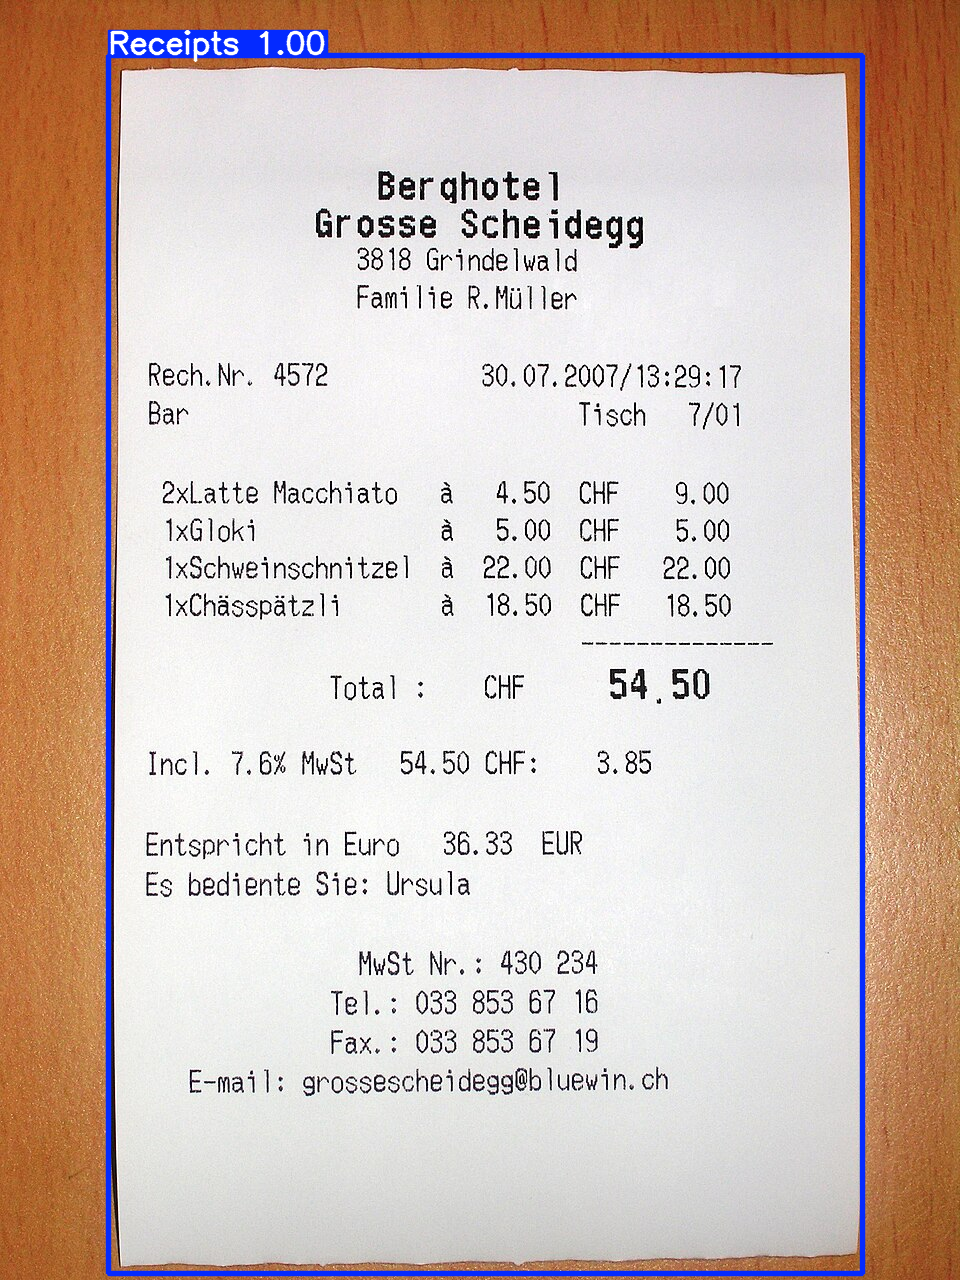

In [45]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
image_path='/content/ReceiptSwiss.jpg'
results =model.predict(source=image_path, conf=0.25)
res_plotted = results[0].plot()
cv2_imshow(res_plotted)
img = cv2.imread("/content/ReceiptSwiss.jpg")
x1, y1, x2, y2 = map(int, results[0].boxes.xyxy[0].tolist())
crop = img[y1:y2, x1:x2]

In [46]:
reader = easyocr.Reader(['en', 'de'])
result = reader.readtext(crop)

In [47]:
nlp = spacy.load("en_core_web_sm")

In [48]:
full_text = " ".join([text for (bbox, text, prob) in result])
doc = nlp(full_text)

In [49]:
from spacy.matcher import Matcher
pttern=[ {"LOWER": "total"},
    {"OP": "?"},
    {"LIKE_NUM": True}]

In [50]:
matcher=Matcher(nlp.vocab)
matcher.add('total',[pttern])

matches = matcher(doc)
for match in matches[:10]:
    print(match,doc[match[1]:match[2]])